# Long Short-Term Memory (LSTM)
Implementations of:
1) Stacked (Deep) LSTM
2) Bidirectional LSTM (BiLSTM)
3) Multilayer LSTM
4) Stateful LSTM
5) Residual LSTM

Dataset: Apple Stock (AAPL – Closing Price)
Task: Time-series prediction (regression)

Install & Imports

In [ ]:
!pip install yfinance

In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Bidirectional, Input, Add)

Load Dataset

In [ ]:
df = yf.download("AAPL", period="5y")
data = df[['Close']]
data.head(10)

/tmp/ipython-input-1665639882.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", period="5y")
[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2020-12-14,118.547020
2020-12-15,124.485085
2020-12-16,124.416924
2020-12-17,125.283302
2020-12-18,123.297462
2020-12-21,124.825790
2020-12-22,128.378906
2020-12-23,127.483292


Preprocessing

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

window_size = 30

X, y = [], []
for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
X.shape

(1226, 30, 1)

In [ ]:
y.shape

(1226, 1)

In [ ]:
X_train.shape

(980, 30, 1)

In [ ]:
X_test.shape

(246, 30, 1)

In [ ]:
y_train.shape

(980, 1)

In [ ]:
y_test.shape

(246, 1)

In [ ]:
X[0]

array([[0.02956207],
       [0.06393585],
       [0.06354128],
       [0.06855651],
       [0.05706104],
       [0.0659081 ],
       [0.08647608],
       [0.08129162],
       [0.08698327],
       [0.11358067],
       [0.10332463],
       [0.09684439],
       [0.0910403 ],
       [0.0725574 ],
       [0.08157357],
       [0.05672292],
       [0.08106647],
       [0.08743392],
       [0.07013428],
       [0.06912013],
       [0.08089732],
       [0.06973994],
       [0.0597658 ],
       [0.06365417],
       [0.08732121],
       [0.11459486],
       [0.12699207],
       [0.14868669],
       [0.15003945],
       [0.14384053]])

In [ ]:
X[30]

array([[0.11583438],
       [0.08692691],
       [0.09921107],
       [0.10400088],
       [0.09808399],
       [0.11752508],
       [0.1151266 ],
       [0.11597323],
       [0.11089397],
       [0.107395  ],
       [0.10592777],
       [0.1072822 ],
       [0.09497941],
       [0.08171737],
       [0.07534016],
       [0.07624306],
       [0.05440287],
       [0.05361281],
       [0.05073475],
       [0.02612912],
       [0.02765288],
       [0.06450477],
       [0.04943667],
       [0.03216764],
       [0.02127568],
       [0.02855587],
       [0.        ],
       [0.0266935 ],
       [0.02042922],
       [0.03160344]])

In [ ]:
y[0]

array([0.11583438])

In [ ]:
X[31]

array([[0.08692691],
       [0.09921107],
       [0.10400088],
       [0.09808399],
       [0.11752508],
       [0.1151266 ],
       [0.11597323],
       [0.11089397],
       [0.107395  ],
       [0.10592777],
       [0.1072822 ],
       [0.09497941],
       [0.08171737],
       [0.07534016],
       [0.07624306],
       [0.05440287],
       [0.05361281],
       [0.05073475],
       [0.02612912],
       [0.02765288],
       [0.06450477],
       [0.04943667],
       [0.03216764],
       [0.02127568],
       [0.02855587],
       [0.        ],
       [0.0266935 ],
       [0.02042922],
       [0.03160344],
       [0.02635489]])

In [ ]:
y[1]

array([0.08692691])

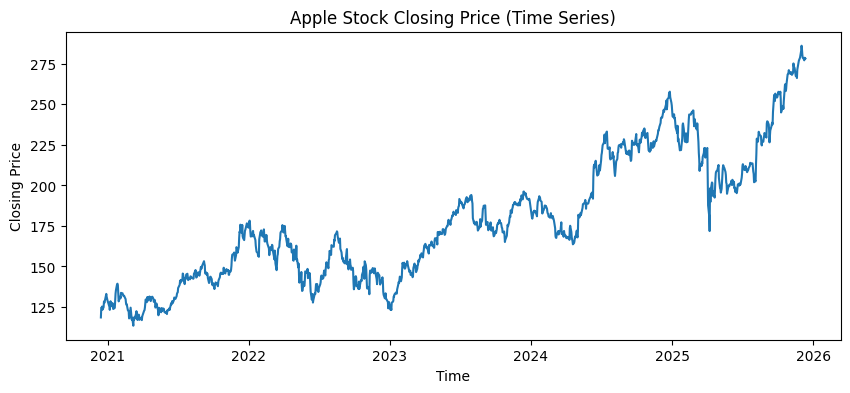

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df['Close'])
plt.title("Apple Stock Closing Price (Time Series)")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.show()

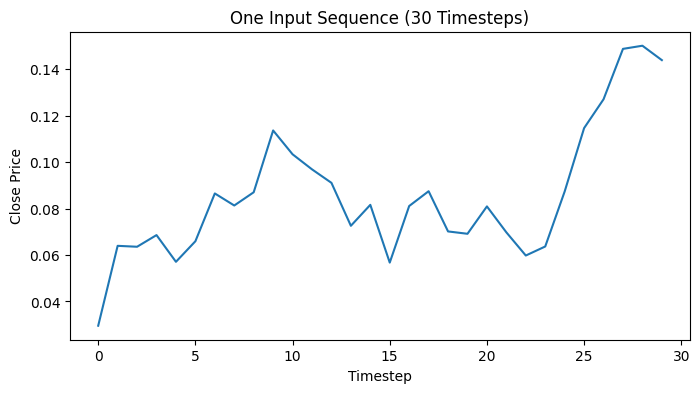

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(X[0])
plt.title("One Input Sequence (30 Timesteps)")
plt.xlabel("Timestep")
plt.ylabel("Close Price")
plt.show()

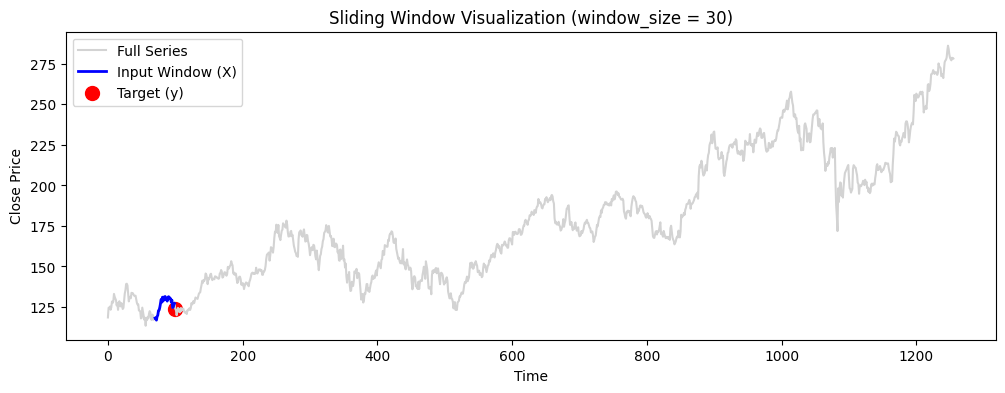

In [ ]:
# Choose a sample index
i = 100

window_size = 30

plt.figure(figsize=(12,4))

# Full series (light background)
plt.plot(df['Close'].values, color='lightgray', label="Full Series")

# Sliding window (X)
plt.plot(range(i-window_size, i),df['Close'].values[i-window_size:i],color='blue',linewidth=2,label="Input Window (X)")

# Target value (y)
plt.scatter(i,df['Close'].values[i],color='red',s=100,label="Target (y)")
plt.title("Sliding Window Visualization (window_size = 30)")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

Utility Function

In [ ]:
def compile_and_train(model, name, epochs=10, batch_size=32):
    model.compile(optimizer='adam', loss='mse')
    history = model.fit(X_train, y_train,epochs=epochs,batch_size=batch_size,verbose=1)
    print(f"{name} trained")
    return history


1) Stacked (Deep) LSTM

In [ ]:
# Hyperparameters
window_size = 30
batch_size = 32
epochs = 10
stacked_lstm = Sequential([Input(shape=(window_size, 1)),LSTM(50, return_sequences=True),LSTM(50),Dense(1)])
stacked_lstm.summary()

hist_stacked = compile_and_train(stacked_lstm, "Stacked LSTM")



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0529
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0022
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0013
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0012
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0012
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0014
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0011
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0012
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0011
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0011
Stacked LSTM trained


Prediction

In [ ]:
# Model Prediction
prediction = stacked_lstm.predict(X_test)
prediction = scaler.inverse_transform(prediction)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step


In [ ]:
actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
    print(f"Predicted: {prediction[i][0]:.2f}, Actual: {actual[i][0]:.2f}")


Predicted: 251.95, Actual: 248.67
Predicted: 252.72, Actual: 253.34
Predicted: 253.61, Actual: 254.12
Predicted: 254.57, Actual: 257.04
Predicted: 255.70, Actual: 257.85
Predicted: 256.93, Actual: 254.44
Predicted: 257.95, Actual: 251.06
Predicted: 258.58, Actual: 249.29
Predicted: 258.78, Actual: 242.75
Predicted: 258.27, Actual: 242.26
Predicted: 257.30, Actual: 243.90
Predicted: 256.14, Actual: 241.12
Predicted: 254.75, Actual: 241.61
Predicted: 253.30, Actual: 235.78
Predicted: 251.55, Actual: 233.34
Predicted: 249.55, Actual: 232.23
Predicted: 247.43, Actual: 236.80
Predicted: 245.63, Actual: 227.23
Predicted: 243.54, Actual: 228.94
Predicted: 241.51, Actual: 221.64
Predicted: 239.18, Actual: 222.82
Predicted: 236.87, Actual: 222.65
Predicted: 234.67, Actual: 221.78
Predicted: 232.63, Actual: 228.83
Predicted: 231.24, Actual: 237.19
Predicted: 230.86, Actual: 238.28
Predicted: 231.26, Actual: 236.52
Predicted: 232.09, Actual: 234.94
Predicted: 233.08, Actual: 226.98
Predicted: 233

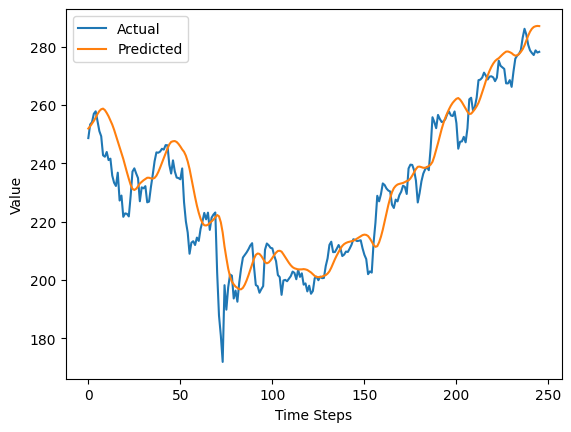

In [ ]:
# Plotting (Actual vs Predicted values)
plt.figure()
plt.plot(actual, label="Actual")
plt.plot(prediction, label="Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.show()


2) Bidirectional LSTM (BiLSTM)

In [ ]:
bilstm = Sequential([Input(shape=(window_size, 1)),Bidirectional(LSTM(50)),Dense(1)])
bilstm.summary()

hist_bilstm = compile_and_train(bilstm, "Bidirectional LSTM")


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 100)            │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,901 (81.64 KB)

 Trainable params: 20,901 (81.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0341
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0038
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0026
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0020
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0016
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0015
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0013
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0010
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 9.5322e-04
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 9.2838e-04
Bidirectional LSTM trained


3) Multilayer LSTM

(Multiple LSTM layers with decreasing units)

In [ ]:
multilayer_lstm = Sequential([Input(shape=(window_size, 1)),LSTM(100, return_sequences=True),LSTM(50, return_sequences=True),LSTM(25),Dense(1)])
multilayer_lstm.summary()

hist_multilayer = compile_and_train(multilayer_lstm, "Multilayer LSTM")

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 30, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 30, 50)         │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,626 (307.13 KB)

 Trainable params: 78,626 (307.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0423
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0033
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0022
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0018
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0018
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0016
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0015
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0014
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - loss: 0.0013
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0014
Multilayer LSTM trained


4) Stateful LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

batch_size = 32

stateful_lstm = Sequential([Input(batch_shape=(batch_size, window_size, 1)),LSTM(50, stateful=True),Dense(1)])

stateful_lstm.compile(optimizer='adam', loss='mse')
stateful_lstm.summary()

# Trim data to match batch size
train_len = len(X_train) - (len(X_train) % batch_size)

X_train_s = X_train[:train_len]
y_train_s = y_train[:train_len]

stateful_losses = []

for epoch in range(10):
    history = stateful_lstm.fit(X_train_s,y_train_s,epochs=1,batch_size=batch_size,shuffle=False,verbose=1    )

    stateful_losses.append(history.history['loss'][0])

    # Reset states safely
    for layer in stateful_lstm.layers:
        if hasattr(layer, "reset_states"):
            layer.reset_states()

print("Stateful LSTM trained successfully")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (32, 50)               │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 1)                │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0125
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0128
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0037
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0041
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0014
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0010
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.7772e-04
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.4391e-04
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.1230e-04
Stateful LSTM trained successfully


5) Residual LSTM

In [ ]:
inputs = Input(shape=(window_size, 1))

x = LSTM(50, return_sequences=True)(inputs)
x = LSTM(50)(x)

shortcut = LSTM(50)(inputs)

output = Add()([x, shortcut])
output = Dense(1)(output)

residual_lstm = tf.keras.Model(inputs, output)
residual_lstm.summary()

hist_residual = compile_and_train(residual_lstm, "Residual LSTM")

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_18 (LSTM)      │ (None, 30, 50)    │     10,400 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_19 (LSTM)      │ (None, 50)        │     20,200 │ lstm_18[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_20 (LSTM)      │ (None, 50)        │     10,400 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50)        │          0 │ lstm_19[0][0],    │
│                     │                   │            │ lstm_20[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         51 │ add_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,051 (160.36 KB)

 Trainable params: 41,051 (160.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 0.0633
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0029
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0014
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0013
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0012
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0012
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0010
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0011
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0011
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 9.4872e-04
Residual LSTM trained


Training Loss Comparison

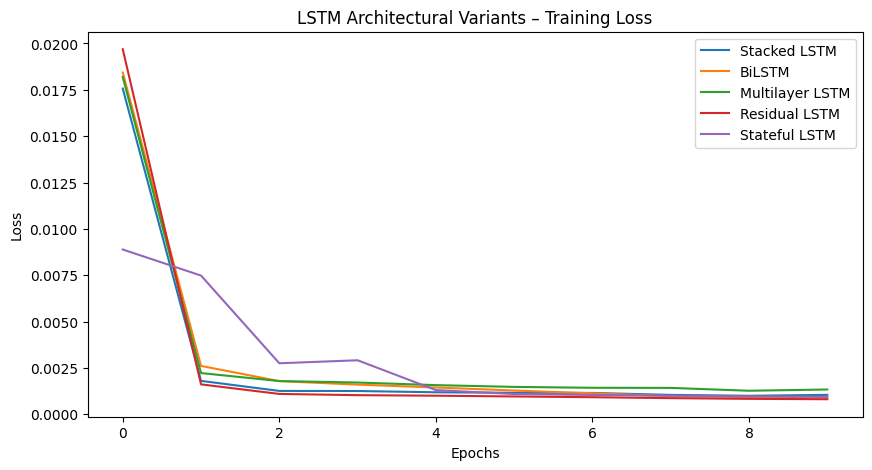

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(hist_stacked.history['loss'], label='Stacked LSTM')
plt.plot(hist_bilstm.history['loss'], label='BiLSTM')
plt.plot(hist_multilayer.history['loss'], label='Multilayer LSTM')
plt.plot(hist_residual.history['loss'], label='Residual LSTM')
plt.plot(stateful_losses, label='Stateful LSTM')

plt.title("LSTM Architectural Variants – Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()